# Data Demo: Predicting 3-day VIX change from Fed text

This notebook demonstrates the project's data loader on a small bundled subset of the corpus (~10 representative documents). It shows example data located at `data/example/` in this repo.

**Inputs:** the first 80 sentences of a Federal Reserve document, encoded one-at-a-time with a frozen FinBERT (`yiyanghkust/finbert-pretrain`) and mask-weighted mean-pooled into one 768-d vector per sentence.

**Target:** the 3-day close-to-close change in the CBOE VIX (FRED ticker `VIXCLS`) following the document's release date, aligned to the next available trading day when a release falls on a weekend or U.S. market holiday.

**Sources:** FOMC minutes (1993 to present, ~268 docs) and Humphrey-Hawkins / Semiannual Monetary Policy Report testimony (1997 to present, ~58 docs). 326 docs total in the full corpus; this notebook shows a 10-doc demo subset.

## Install the project package

If you have already run `pip install -e .` in this kernel's Python, this cell is a no-op. Otherwise it installs the package in editable mode so the imports below work.

In [4]:
import sys, subprocess
from pathlib import Path

# Find repo root by walking up until we see pyproject.toml.
_here = Path.cwd()
for candidate in [_here, *list(_here.parents)]:
    if (candidate / "pyproject.toml").exists():
        repo_root = candidate
        break
else:
    raise RuntimeError("Could not find repo root: no pyproject.toml in CWD or any parent directory.")

try:
    import transcripts_fed_vix  # noqa: F401
    print(f"Package already installed in this kernel.")
except ModuleNotFoundError:
    print(f"Installing transcripts_fed_vix from {repo_root} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_root)])
    print("Done. Note: you may need to restart the kernel for fresh imports to take effect.")

Package already installed in this kernel.


## 1. Load the example documents

`load_example_documents()` reads the bundled JSON and returns a DataFrame whose schema matches the full processed parquet: `doc_id`, `source`, `release_date`, `aligned_trading_date`, `vix_t`, `vix_t_plus_3`, `target`, `sentences`.

In [8]:
import torch
from transcripts_fed_vix.data import load_example_documents, get_example_dataloader

documents = load_example_documents()
print(f"Loaded {len(documents)} example documents.")
print(f"Date range: {documents['release_date'].min().date()} .. {documents['release_date'].max().date()}")
documents[["doc_id", "source", "release_date", "vix_t", "vix_t_plus_3", "target"]]

Loaded 10 example documents.
Date range: 1993-02-03 .. 2026-04-29


,doc_id,source,release_date,vix_t,vix_t_plus_3,target
0,fomc_19930203,fomc,1993-02-03,12.12,13.22,1.10
1,fomc_19930323,fomc,1993-03-23,13.02,12.21,-0.81
2,hh_19970226,humphrey_hawkins,1997-02-26,20.74,20.89,0.15
3,hh_19970722,humphrey_hawkins,1997-07-22,21.77,20.82,-0.95
4,hh_20040720,humphrey_hawkins,2004-07-20,14.17,16.50,2.33
5,fomc_20040810,fomc,2004-08-10,17.47,17.98,0.51
6,fomc_20150429,fomc,2015-04-29,13.39,12.85,-0.54
7,fomc_20150617,fomc,2015-06-17,14.50,12.74,-1.76
8,fomc_20260318,fomc,2026-03-18,25.09,26.15,1.06
9,fomc_20260429,fomc,2026-04-29,18.81,18.29,-0.52


## 2. Inspect one document's text

Each row's `sentences` column is a list of strings (first 20 here in the bundled subset; up to 80 in the full corpus; see methodology doc for why).

In [3]:
row = documents.iloc[0]
print(f"Document: {row['doc_id']}")
print(f"  source:               {row['source']}")
print(f"  release_date:         {row['release_date'].date()}")
print(f"  aligned_trading_date: {row['aligned_trading_date'].date()}")
print(f"  vix_t:                {row['vix_t']:.2f}")
print(f"  vix_t_plus_3:         {row['vix_t_plus_3']:.2f}")
print(f"  target (3-day change): {row['target']:+.2f}")
print(f"  number of sentences:  {len(row['sentences'])}")
print("\nFirst 3 sentences:")
for i, s in enumerate(row["sentences"][:3], 1):
    print(f"  [{i}] {s}")

Document: fomc_19930203
  source:               fomc
  release_date:         1993-02-03
  aligned_trading_date: 1993-02-03
  vix_t:                12.12
  vix_t_plus_3:         13.22
  target (3-day change): +1.10
  number of sentences:  20

First 3 sentences:
  [1] Minutes of the Federal Open Market Committee Meeting of February 2-3, 1993 A meeting of the Federal Open Market Committee was held in the offices of the Board of Governors of the Federal Reserve System in Washington, D.C., on Tuesday, February 2, 1993, at 2:30 p.m. and was continued on Wednesday, February 3, 1993, at 9:00 a.m.
  [2] PRESENT: Mr. Greenspan, Chairman Mr. Corrigan, Vice Chairman Mr. Angell Mr. Boehne Mr. Keehn Mr. Kelley Mr. LaWare Mr. Lindsey Mr. McTeer Mr. Mullins Ms. Phillips Mr. Stern Messrs. Broaddus, Jordan, Forrestal, and Parry, Alternate Members of the Federal Open Market Committee Messrs. Hoenig, Melzer, and Syron, Presidents of the Federal Reserve Banks of Kansas City, St. Louis, and Boston, respecti

## 3. The training DataLoader: one batch end-to-end

`get_example_dataloader()` returns a standard `torch.utils.data.DataLoader`. Each batch is a dict containing the pre-computed FinBERT embeddings, an attention mask, the regression target, and metadata (doc IDs and release dates).

Embeddings are pre-computed because the FinBERT encoder is fully frozen, so there's no information-leakage risk to caching them once and reusing them every training epoch. This speeds training by orders of magnitude (we only train the small attention aggregator + linear head, ~100k parameters, on top of the cached embeddings).

In [5]:
loader = get_example_dataloader(batch_size=4)
batch = next(iter(loader))

print("Batch keys:", list(batch.keys()))
print(f"  embeddings:    {tuple(batch['embeddings'].shape)}  dtype={batch['embeddings'].dtype}")
print(f"  mask:          {tuple(batch['mask'].shape)}        dtype={batch['mask'].dtype}")
print(f"  target:        {tuple(batch['target'].shape)}        dtype={batch['target'].dtype}")
print(f"  doc_ids:       {batch['doc_ids']}")
print(f"  release_dates: {[d.date() for d in batch['release_dates']]}")
print(f"  target values: {batch['target'].tolist()}")

Batch keys: ['embeddings', 'mask', 'target', 'doc_ids', 'release_dates']
  embeddings:    (4, 20, 768)  dtype=torch.float32
  mask:          (4, 20)        dtype=torch.float32
  target:        (4,)        dtype=torch.float32
  doc_ids:       ['fomc_19930203', 'fomc_19930323', 'hh_19970226', 'hh_19970722']
  release_dates: [datetime.date(1993, 2, 3), datetime.date(1993, 3, 23), datetime.date(1997, 2, 26), datetime.date(1997, 7, 22)]
  target values: [1.100000023841858, -0.8100000023841858, 0.15000000596046448, -0.949999988079071]


## 4. Target distribution in the demo subset

Each document's target is the *change* in the VIX over the 3 trading days following its release. Positive = volatility went up after the Fed spoke; negative = it went down.

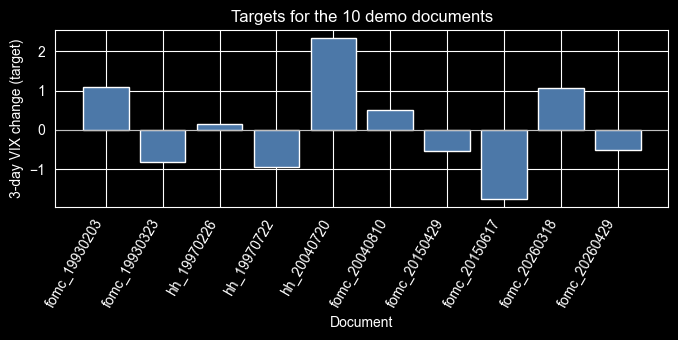

In [6]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(documents["doc_id"], documents["target"], color="#4C78A8")
ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.set_ylabel("3-day VIX change (target)")
ax.set_xlabel("Document")
ax.set_title("Targets for the 10 demo documents")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 5. Run the trained model on the demo docs and visualize attention

If `data/example/example_model.pt` is present (the trained checkpoint exported alongside the demo data), we can run a forward pass and see which sentences the attention layer weighted most heavily for one document.

In [7]:
from transcripts_fed_vix.models import SentenceAttentionModel
from transcripts_fed_vix.models.attention import AttentionConfig

model_path = repo_root / "data" / "example" / "example_model.pt"
if model_path.exists():
    model = SentenceAttentionModel(AttentionConfig())
    model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
    model.eval()
    with torch.no_grad():
        out = model(batch["embeddings"], batch["mask"])
    for i, doc_id in enumerate(batch["doc_ids"]):
        n_real = int(batch["mask"][i].sum())
        print(f"\n{doc_id}  target={batch['target'][i].item():+.2f}  pred={out.prediction[i].item():+.2f}")
        top = torch.topk(out.attention_weights[i, :n_real], k=min(3, n_real))
        print("  Top-3 attended sentences:")
        sents = documents.set_index("doc_id").loc[doc_id, "sentences"]
        for idx, w in zip(top.indices.tolist(), top.values.tolist()):
            print(f"    weight={w:.3f}  {sents[idx][:120]}")
else:
    print(f"No trained model at {model_path}; skipping this cell. "
          "Run scripts/export_examples.py on Talapas after training to bundle one.")


fomc_19930203  target=+1.10  pred=-0.03
  Top-3 attended sentences:
    weight=0.061  4.
    weight=0.056  At the meeting; the Committee voted unanimously to update the references to the Management of the System Open Market Acc
    weight=0.055  Attended portion of meeting relating to the Committee's discussion of the economic outlook and its longer-run objectives

fomc_19930323  target=-0.81  pred=-0.07
  Top-3 attended sentences:
    weight=0.060  The Committee then turned to a discussion of the economic outlook and the implementation of monetary policy over the int
    weight=0.057  Merging the two documents would put in convenient form all the information that is released pertaining to FOMC meetings,
    weight=0.056  The Manager of the System Open Market Account reported on developments in foreign exchange markets since the previous me

hh_19970226  target=+0.15  pred=-0.06
  Top-3 attended sentences:
    weight=0.056  At the same time, continued low levels of inflation and infla

## Next steps

- Full scrape + training pipeline lives in `scripts/train.sbatch` (SLURM job)
- Methodology and design-decision rationale: `docs/METHODOLOGY.md`
- Project milestone summary: `docs/MILESTONE_REPORT.md`